In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from dataset_generation_static import generate_dataset, sm_generative_model, get_dataset_parameters
from wassa_plots_static import plot_random_trial, plot_averaged, plot_kernels, plot_stats

# Generative model for raster plots and spiking motifs

List of parameters for this generative model

In [14]:
dataset_parameters = {
    'seed' : 666,
    
    'N_pre' : 10, # number of neurons
    'N_timesteps' : 51, # number of timesteps for the raster plot (in ms)
    'N_samples' : 60, # total number of samples in the dataset
    'N_sms' : 2, # number of structured spiking motifs

    'temporal_jitter' : 1, # temporal jitter for the spike generation in motifs
    'dropout_proba' : .1, # probabilistic participations of the different neurons to the spiking motif
    'additive_noise' : .6, # percentage of background noise/spontaneous activity
    'min_warping_coef' : .6, # coefficient for time warping
}
dataset_parameters.update({'N_involved':dataset_parameters['N_pre']*torch.ones(dataset_parameters['N_sms'])}) # number of neurons involved in the spiking motif
dataset_parameters.update({'proba_sms' : torch.ones(dataset_parameters['N_sms'])/dataset_parameters['N_sms']}) # probability of apparition of the different spiking motif

In [15]:
model = sm_generative_model_static(dataset_parameters)
raster_plot, motifs_occurence = model.draw_input(dataset_parameters['N_samples'])

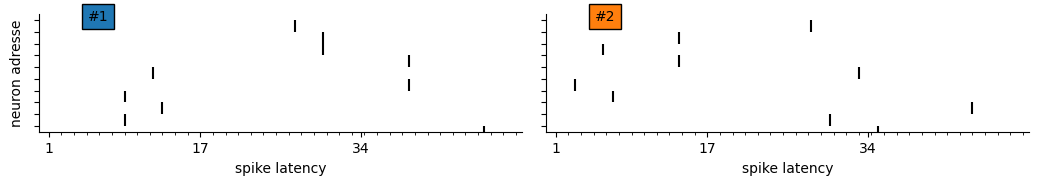

In [16]:
plot_kernels(model);

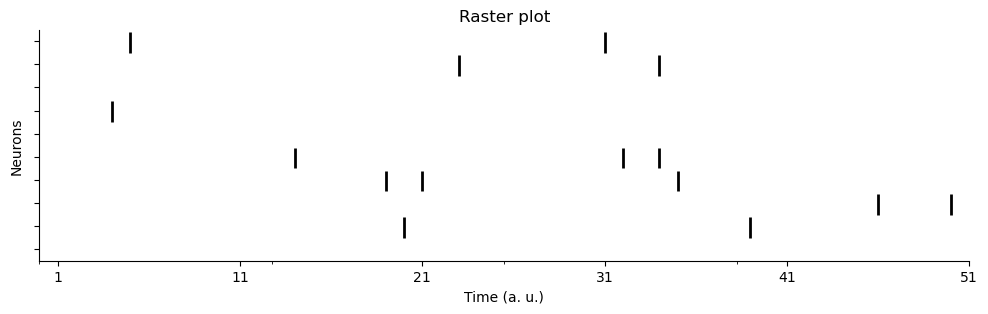

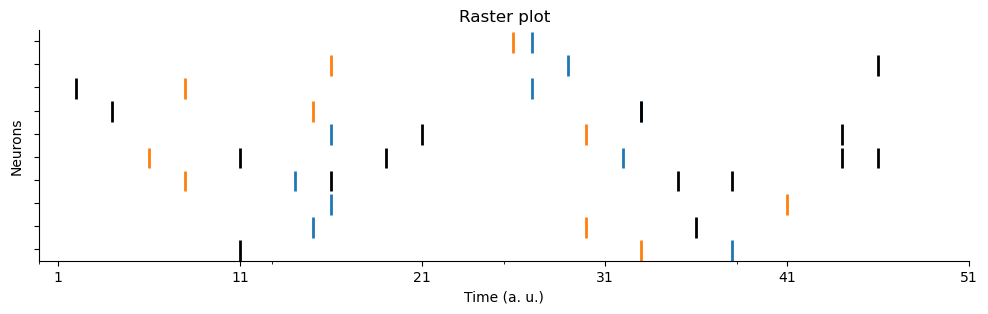

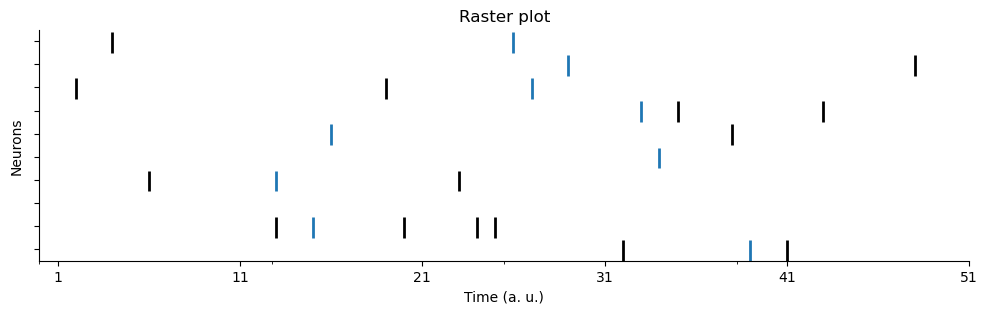

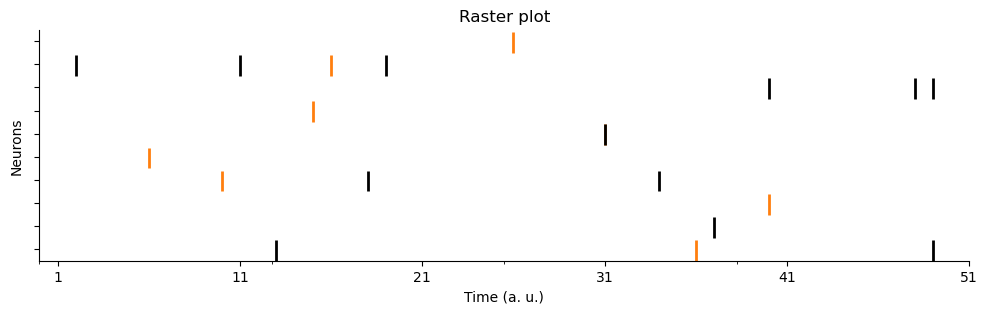

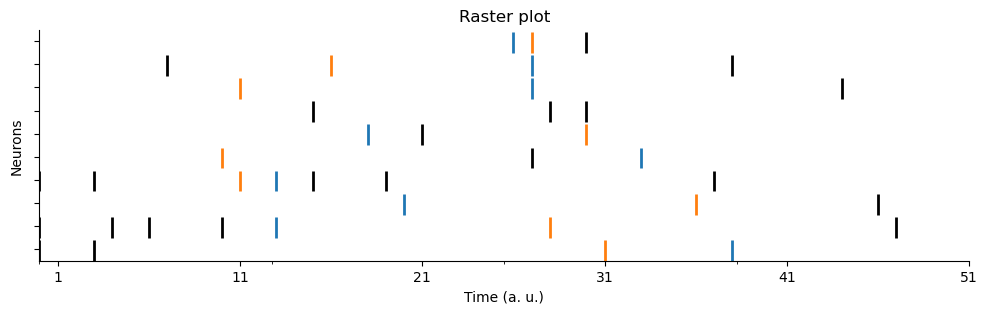

In [17]:
nb_trials = 5
for i in range(nb_trials):
    plot_random_trial(raster_plot)

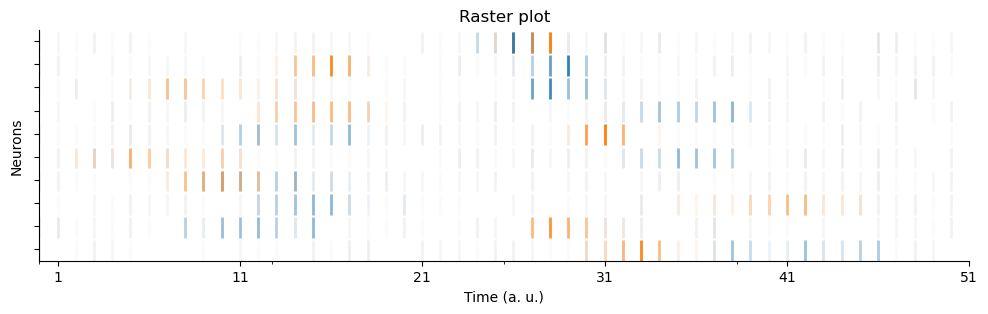

In [18]:
plot_averaged(raster_plot)

The generative model will draw raster plots generated from both a spontaneous (random) activity and from spiking motifs. There are *parameters.N_SM* spiking motifs represented in the next plot. There are given as a spiking probability for each presynatpic neuron and each timestep (or delay). 

The raster plot is produced with a sequence of apparition of the different motifs and random activity when no motif occurs. 

The instantaneous firing rate sumed over the different trials shows that the distribution is Poisson. And we can check the effective number of spikes per neuron compared to the expected firing rate. Firing rate of the different neurons can be easily changed, default is chosen by following a normal distribution around an average firing rate.  

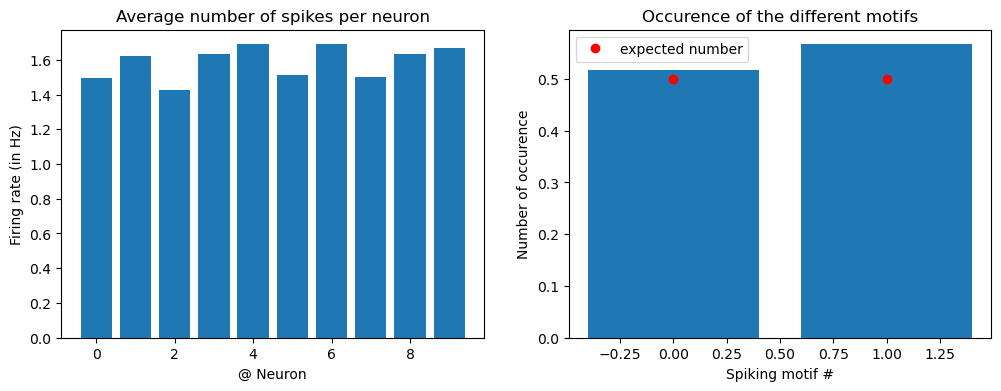

In [19]:
plot_stats(raster_plot, motifs_occurence, dataset_parameters)

We can also check the number of occurence of the motifs and compare it to the expected number of occurence.

## Save a dataset

You can also easily save a dataset with a defined number of trials (*total_number_of_trials*). It will split the dataset into a training (80% of the trials) and a testing (20% of the trials) of the trials sets. 

In [20]:
sm, dataset_input, dataset_output = generate_static_dataset(dataset_parameters)

../synthetic_data_static/generative_model_6661051210.10.60.610.010.00.50.5
